# Taller práctico — Aprendizaje no supervisado

## Segmentación de usuarios de Steam

**Objetivo.** Entender qué tipos de usuarios hay en Steam. Para ello se resumen las compras y horas de juego de cada persona, se forman grupos parecidos y se proponen ideas de marketing para cada grupo.

> Importante: cuando `action` es `play`, la columna `value` indica horas jugadas. Cuando es `purchase`, siempre vale 1; por eso indica que hubo una compra, pero no dice cuánto dinero pagó el usuario.

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score, silhouette_score
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore', category=FutureWarning)
SEED = 42
DATA_PATH = Path('steam-200k.csv')
sns.set_theme(style='whitegrid', palette='deep')
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

## 1. Exploración de los datos

El archivo no trae nombres de columnas. Primero se agregan nombres sencillos para saber qué representa cada dato: usuario, juego, acción y valor. También se revisa si la última columna aporta algo.

In [11]:
columns = ['user_id', 'game', 'action', 'value', 'zero']
df_raw = pd.read_csv(DATA_PATH, header=None, names=columns)

print(f'Dimensiones: {df_raw.shape[0]:,} filas x {df_raw.shape[1]} columnas')
print(f'Usuarios únicos: {df_raw.user_id.nunique():,}')
print(f'Videojuegos únicos: {df_raw.game.nunique():,}')
display(df_raw.head())
display(pd.DataFrame({'tipo': df_raw.dtypes.astype(str), 'nulos': df_raw.isna().sum(), 'valores_unicos': df_raw.nunique()}))

Dimensiones: 200,000 filas x 5 columnas
Usuarios únicos: 12,393
Videojuegos únicos: 5,155


,user_id,game,action,value,zero
0,151603712,The Elder Scrolls V Skyrim,purchase,1.00,0
1,151603712,The Elder Scrolls V Skyrim,play,273.00,0
2,151603712,Fallout 4,purchase,1.00,0
3,151603712,Fallout 4,play,87.00,0
4,151603712,Spore,purchase,1.00,0


,tipo,nulos,valores_unicos
user_id,int64,0,12393
game,str,0,5155
action,str,0,2
value,float64,0,1593
zero,int64,0,1


In [3]:
print('Valores nulos por columna:')
display(df_raw.isna().sum().to_frame('nulos'))
print(f'Registros duplicados exactos: {df_raw.duplicated().sum():,}')
print(f'Duplicados por usuario, juego y acción: {df_raw.duplicated(["user_id", "game", "action"]).sum():,}')
print(f'Valores distintos de la columna auxiliar: {df_raw.zero.unique()}')

print('Estadísticos de variables numéricas:')
display(df_raw[['user_id', 'value', 'zero']].describe().T)
print('Estadísticos de horas, solo para interacciones de juego:')
display(df_raw.loc[df_raw.action.eq('play'), 'value'].describe().to_frame('hours'))

Valores nulos por columna:


,nulos
user_id,0
game,0
action,0
value,0
zero,0


Registros duplicados exactos: 707
Duplicados por usuario, juego y acción: 719
Valores distintos de la columna auxiliar: [0]
Estadísticos de variables numéricas:


,count,mean,std,min,25%,50%,75%,max
user_id,"200,000.00","103,655,865.95","72,080,735.13","5,250.00","47,384,202.00","86,912,006.00","154,230,933.00","309,903,146.00"
value,"200,000.00",17.87,138.06,0.10,1.00,1.00,1.30,"11,754.00"
zero,"200,000.00",0.00,0.00,0.00,0.00,0.00,0.00,0.00


Estadísticos de horas, solo para interacciones de juego:


,hours
count,"70,489.00"
mean,48.88
std,229.34
min,0.10
25%,1.00
50%,4.50
75%,19.10
max,"11,754.00"


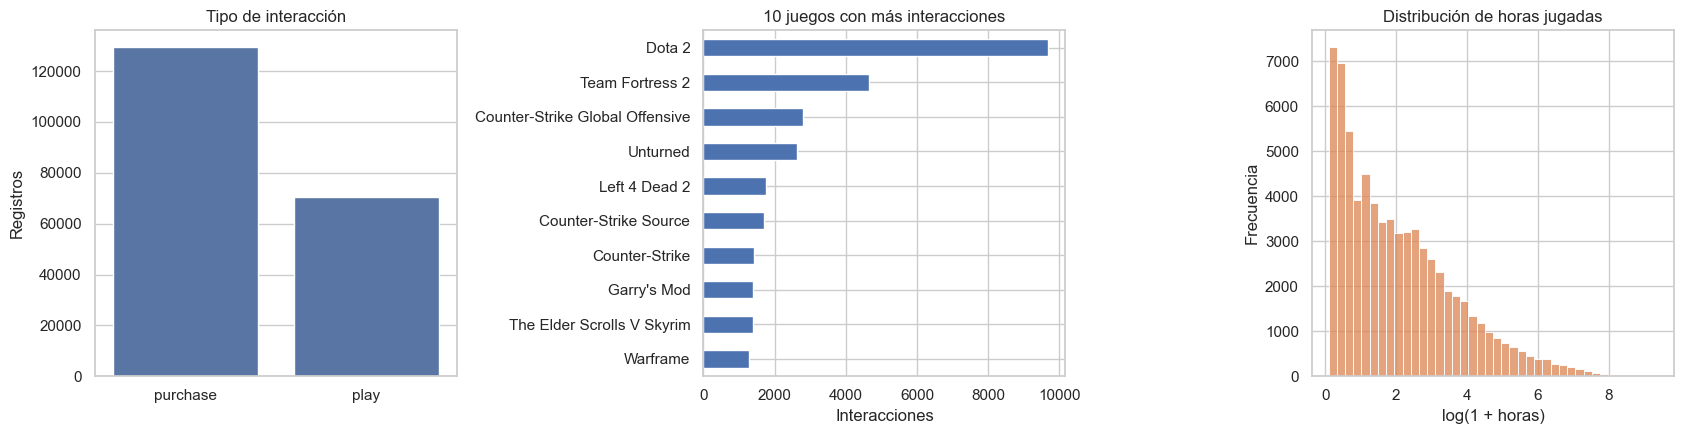

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

sns.countplot(data=df_raw, x='action', ax=axes[0])
axes[0].set(title='Tipo de interacción', xlabel='', ylabel='Registros')

top_games = df_raw.game.value_counts().head(10).sort_values()
top_games.plot.barh(ax=axes[1], color='#4C72B0')
axes[1].set(title='10 juegos con más interacciones', xlabel='Interacciones', ylabel='')

play_hours = df_raw.loc[df_raw.action.eq('play'), 'value']
sns.histplot(np.log1p(play_hours), bins=40, ax=axes[2], color='#DD8452')
axes[2].set(title='Distribución de horas jugadas', xlabel='log(1 + horas)', ylabel='Frecuencia')
plt.tight_layout()
plt.show()

### Lo que encontramos

- Hay **200.000** registros, **12.393** usuarios y **5.155** videojuegos. No existen valores nulos.
- Se encuentran **707 duplicados exactos**, que se eliminan para no inflar compras u horas.
- Hay unos pocos usuarios con muchísimas horas o muchos juegos. Se ajustan esos valores para que no definan los grupos por sí solos.
- El número de usuario no se usa para formar los grupos porque solo sirve para identificar a la persona. Tampoco se usa directamente el nombre del juego: hay 5.155 títulos y el resultado sería difícil de leer.

## 2. Preparación y construcción de variables por usuario

El archivo original tiene una fila por cada acción: una compra o una sesión de juego. Para comparar personas, se crea una sola fila por usuario con un resumen de su actividad:

- `games_purchased`: juegos distintos que compró.
- `games_played`: juegos distintos que sí jugó.
- `total_hours`: horas que jugó en total.
- `avg_hours_per_played_game`: promedio de horas por juego jugado.
- `activation_rate`: parte de los juegos comprados que sí llegó a jugar.
- `hours_per_owned_game`: horas jugadas por cada juego que tiene.

Si una persona compró, pero no jugó, sus valores de juego se dejan en cero. No es un dato perdido: muestra que todavía no ha usado sus compras.

In [ ]:
# 1) Eliminar duplicados exactos y la columna constante.
df = df_raw.drop_duplicates().drop(columns='zero').copy()

# 2) Agregar compras y juego a nivel de usuario.
purchases = (df[df.action.eq('purchase')]
             .groupby('user_id')['game'].nunique()
             .rename('games_purchased'))
plays = (df[df.action.eq('play')]
         .groupby('user_id')
         .agg(games_played=('game', 'nunique'),
              total_hours=('value', 'sum'),
              avg_hours_per_played_game=('value', 'mean'),
              median_hours_per_played_game=('value', 'median')))

users = purchases.to_frame().join(plays, how='left').fillna(0)
users['activation_rate'] = users['games_played'] / users['games_purchased']
users['hours_per_owned_game'] = users['total_hours'] / users['games_purchased']

features = ['games_purchased', 'games_played', 'total_hours',
            'avg_hours_per_played_game', 'activation_rate', 'hours_per_owned_game']

print(f'Filas tras deduplicar: {len(df):,}')
print(f'Matriz final usuario-características: {users.shape[0]:,} x {len(features)}')
display(users[features].describe().T)

Filas tras deduplicar: 199,293
Matriz final usuario-características: 12,393 × 6


,count,mean,std,min,25%,50%,75%,max
games_purchased,"12,393.00",10.39,35.64,1.00,1.00,2.00,6.00,"1,068.00"
games_played,"12,393.00",5.69,17.08,0.00,1.00,1.00,3.00,498.00
total_hours,"12,393.00",278.01,760.27,0.00,1.30,13.50,155.60,"11,754.00"
avg_hours_per_played_game,"12,393.00",74.32,283.75,0.00,1.10,7.90,39.00,"11,754.00"
activation_rate,"12,393.00",0.73,0.34,0.00,0.50,1.00,1.00,1.00
hours_per_owned_game,"12,393.00",55.47,241.30,0.00,0.83,5.68,27.50,"11,754.00"


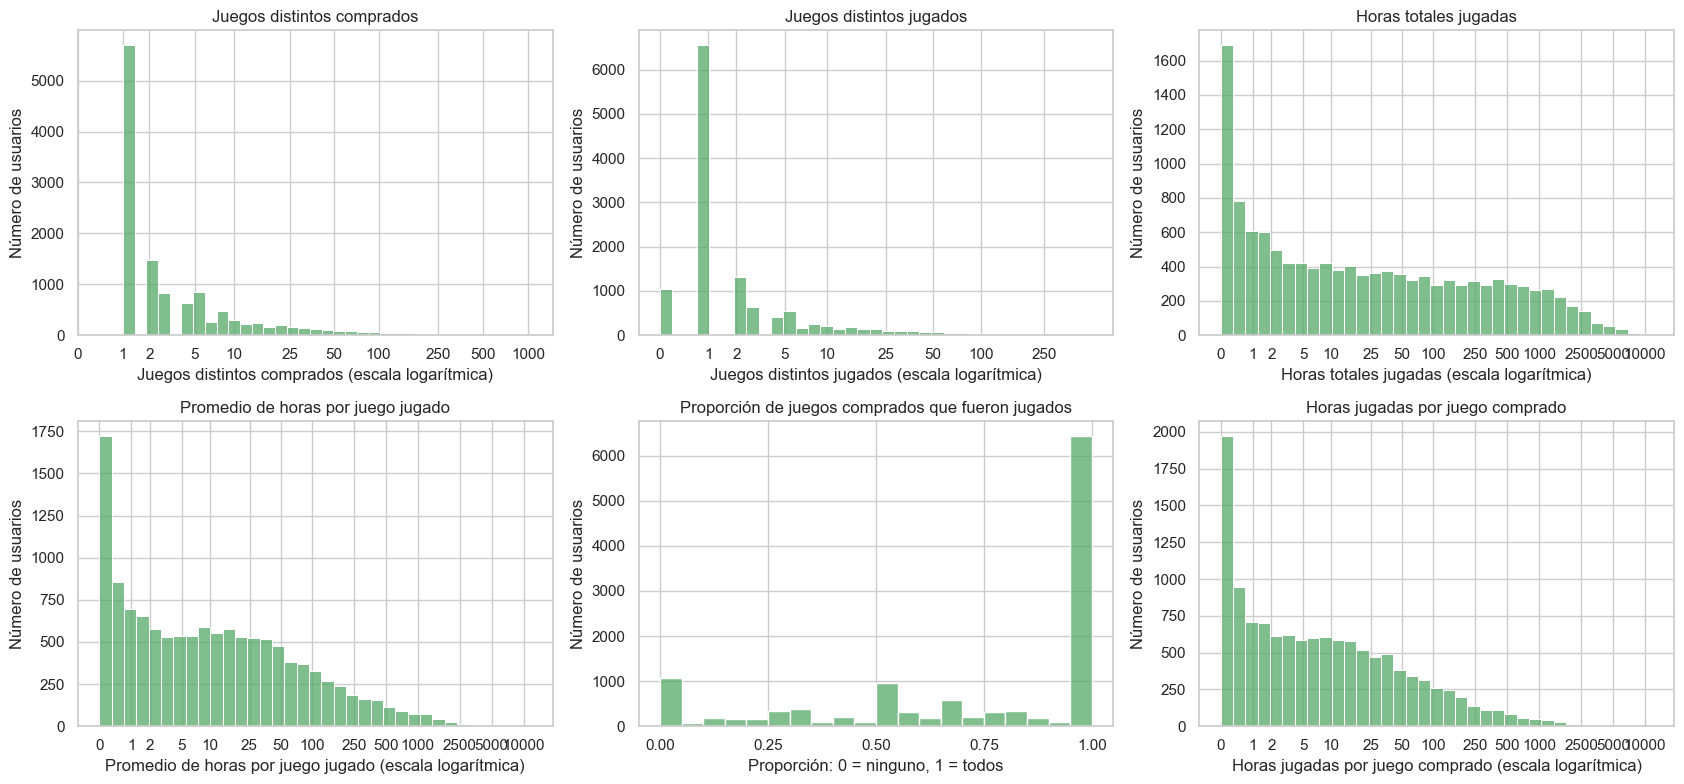

In [ ]:
variables_log = ['games_purchased', 'games_played', 'total_hours',
                 'avg_hours_per_played_game', 'hours_per_owned_game']
X_model = users[features].copy()
X_model[variables_log] = np.log1p(X_model[variables_log])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_model)

labels = {
    'games_purchased': 'Juegos distintos comprados',
    'games_played': 'Juegos distintos jugados',
    'total_hours': 'Horas totales jugadas',
    'avg_hours_per_played_game': 'Promedio de horas por juego jugado',
    'activation_rate': 'Proporción de juegos comprados que fueron jugados',
    'hours_per_owned_game': 'Horas jugadas por juego comprado'
}
marcas = [0, 1, 2, 5, 10, 25, 50, 100, 250, 500, 1000, 2500, 5000, 10000]

fig, axes = plt.subplots(2, 3, figsize=(17, 8))
for ax, feature in zip(axes.flat, features):
    if feature == 'activation_rate':
        sns.histplot(users[feature], bins=20, ax=ax, color='#55A868')
        ax.set_xlabel('Proporción: 0 = ninguno, 1 = todos')
        ax.set_xticks([0, 0.25, 0.5, 0.75, 1])
    else:
        sns.histplot(X_model[feature], bins=35, ax=ax, color='#55A868')
        ticks_validos = [x for x in marcas if x <= users[feature].max()]
        ax.set_xticks(np.log1p(ticks_validos))
        ax.set_xticklabels(ticks_validos)
        ax.set_xlabel(f'{labels[feature]} (escala logarítmica)')
    ax.set_title(labels[feature])
    ax.set_ylabel('Número de usuarios')
plt.tight_layout()
plt.show()

## 3. Modelado

Se usa **K-Means**, una herramienta que junta usuarios con hábitos parecidos. Funciona bien aquí porque se comparan números simples, como cantidad de juegos y horas.

Se prueban entre 2 y 8 grupos. Elegimos 4 porque, entre las opciones revisadas, deja grupos más claros y mejor separados. Las tres medidas mostradas en la tabla se usan solo como apoyo para tomar esa decisión.

,k,silhouette,davies_bouldin,calinski_harabasz
0,2,0.41,1.05,"9,406.00"
1,3,0.41,0.93,"9,120.00"
2,4,0.44,0.85,"10,771.00"
3,5,0.42,0.92,"10,580.00"
4,6,0.42,0.91,"10,575.00"
5,7,0.43,0.96,"10,385.00"
6,8,0.43,0.95,"10,291.00"


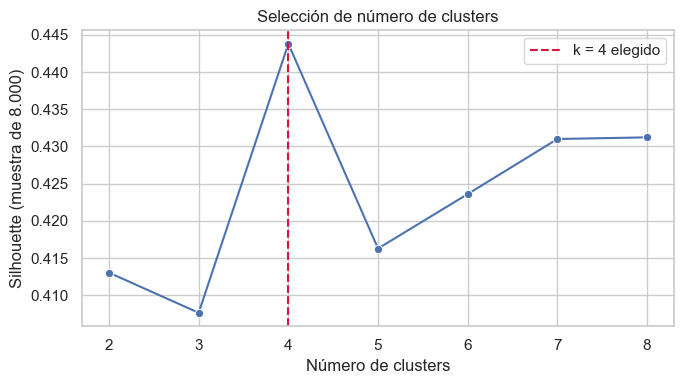

In [ ]:
scores = []
for k in range(2, 9):
    model = KMeans(n_clusters=k, random_state=SEED, n_init=20)
    labels = model.fit_predict(X_scaled)
    scores.append({
        'k': k,
        'silhouette': silhouette_score(X_scaled, labels, sample_size=8_000, random_state=SEED),
        'davies_bouldin': davies_bouldin_score(X_scaled, labels),
        'calinski_harabasz': calinski_harabasz_score(X_scaled, labels)
    })

metrics = pd.DataFrame(scores)
display(metrics.round({'silhouette': 3, 'davies_bouldin': 3, 'calinski_harabasz': 0}))

fig, ax = plt.subplots(figsize=(7, 4))
sns.lineplot(data=metrics, x='k', y='silhouette', marker='o', ax=ax)
ax.axvline(4, ls='--', color='crimson', label='k = 4 elegido')
ax.set(title='Selección de número de clusters', ylabel='Silhouette (muestra de 8.000)', xlabel='Número de clusters')
ax.legend()
plt.tight_layout()
plt.show()

kmeans = KMeans(n_clusters=4, random_state=SEED, n_init=20)
users['cluster_id'] = kmeans.fit_predict(X_scaled)

## 4. Interpretación de los clusters

Los números que entrega el programa no tienen un significado propio; por eso se cambian por nombres fáciles de entender. Se muestran promedios y valores del usuario típico. Esto ayuda porque unos pocos jugadores con muchas horas pueden subir mucho el promedio.

In [9]:
segment_names = {
    0: 'Casuales activos',
    1: 'Dedicados especialistas',
    2: 'Coleccionistas multijuego',
    3: 'Compradores sin activar'
}
users['segment'] = users['cluster_id'].map(segment_names)

profile_mean = (users.groupby('segment')[features]
                .mean()
                .join(users.groupby('segment').size().rename('users'))
                .assign(percent=lambda x: 100 * x['users'] / len(users))
                [['users', 'percent'] + features]
                .sort_values('users', ascending=False))
profile_median = users.groupby('segment')[features].median().reindex(profile_mean.index)

print('Perfil por medias:')
profile_mean_display = profile_mean.round(2).copy()
profile_mean_display['percent'] = profile_mean_display['percent'].map(lambda x: f'{x:.1f}%')
display(profile_mean_display)
print('Perfil por medianas:')
display(profile_median.round(2))

Perfil por medias:


,users,percent,games_purchased,games_played,total_hours,avg_hours_per_played_game,activation_rate,hours_per_owned_game
segment,,,,,,,,
Casuales activos,5345,43.1%,1.68,1.44,6.83,4.62,0.94,4.25
Dedicados especialistas,3186,25.7%,3.44,2.17,439.88,250.87,0.79,191.01
Compradores sin activar,1947,15.7%,4.29,0.66,3.09,2.37,0.13,0.51
Coleccionistas multijuego,1915,15.4%,52.48,28.50,"1,045.11",48.28,0.63,28.82


Perfil por medianas:


,games_purchased,games_played,total_hours,avg_hours_per_played_game,activation_rate,hours_per_owned_game
segment,,,,,,
Casuales activos,1.00,1.00,3.00,2.40,1.00,2.20
Dedicados especialistas,2.00,1.00,157.85,89.00,1.00,64.64
Compradores sin activar,3.00,0.00,0.00,0.00,0.00,0.00
Coleccionistas multijuego,27.00,16.00,558.70,26.43,0.66,16.05


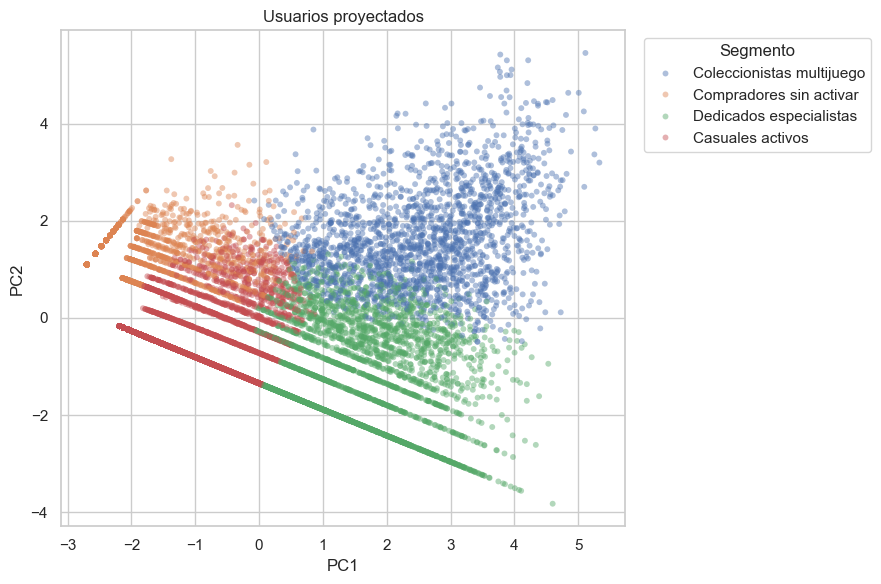

In [13]:
pca = PCA(n_components=2, random_state=SEED)
coords = pca.fit_transform(X_scaled)
plot_df = pd.DataFrame({'PC1': coords[:, 0], 'PC2': coords[:, 1], 'segment': users['segment'].to_numpy()})

plt.figure(figsize=(9, 6))
sns.scatterplot(data=plot_df, x='PC1', y='PC2', hue='segment', alpha=.45, s=18, linewidth=0)
plt.title(f'Usuarios proyectados')
plt.legend(title='Segmento', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Lectura de segmentos

| Segmento | Perfil conductual | Lectura |
|---|---|---|
| Casuales activos | Mayoritario; mediana de 1 juego comprado, 1 jugado y 3 horas totales. | Entran, prueban y juegan poco. |
| Dedicados especialistas | Biblioteca pequeña (mediana 2), pero 158 horas totales y 89 horas por juego jugado. | Muy comprometidos con pocos títulos. |
| Coleccionistas multijuego | Mayor biblioteca (mediana 27) y 16 juegos jugados; 559 horas totales. | Exploran y compran muchos juegos, pero activan cerca de dos tercios de la biblioteca. |
| Compradores sin activar | Mediana de 3 compras, 0 juegos jugados y 0 horas. | Riesgo de abandono, backlog o compras que no se convierten en uso. |

Estos grupos describen lo que aparece en los datos. No permiten saber cuánto dinero gastó cada persona ni asegurar por qué compra o deja de jugar.

## 5. Recomendaciones de negocio

| Segmento | Acción recomendada | Promoción / mensaje | Prioridad |
|---|---|---|---|
| Casuales activos | Reducir fricción para volver a jugar y llevarlos a un segundo título. | Recomendaciones simples, prueba gratuita o descuento moderado en juegos afines al único título jugado. | Media: gran volumen, bajo uso individual. |
| Dedicados especialistas | Retener en su ecosistema de interés y evitar fatiga comercial. | DLC, expansiones, contenido estacional y comunidad del juego principal; no descuentos masivos de catálogo. | Alta: alto compromiso. |
| Coleccionistas multijuego | Convertir biblioteca en horas de juego y mejorar descubrimiento. | Bundles personalizados, curaduría por género y campañas de “juega lo que ya tienes”; evitar recomendar títulos ya adquiridos. | Alta: potencial de compra cruzada y activación. |
| Compradores sin activar | Activación temprana, no venta agresiva. | Recordatorio del juego adquirido, guía de inicio, incentivo por primera sesión; si no activan, encuesta breve. | Muy alta para reactivación, pero no para inversión publicitaria ilimitada. |

### Datos que ayudarían a mejorar el análisis

Ayudaría tener la fecha de compra y de última sesión, precio, género del juego, descuentos, país, dispositivo, amigos, logros, reseñas y campañas recibidas. Sin esos datos no es correcto decir que un grupo es el más rentable ni afirmar que una promoción causó una compra.

## Conclusión

Se encontraron cuatro tipos de usuarios con comportamientos distintos. Esta división sirve como punto de partida para diseñar campañas, pero puede cambiar si se consiguen más datos, por ejemplo precios, fechas y géneros de juegos. Lo ideal sería revisar los grupos cada cierto tiempo y comprobar si las campañas logran que más personas jueguen y regresen.

## Fuentes de apoyo

- [Documentación de K-Means — scikit-learn](https://scikit-learn.org/stable/modules/clustering.html#k-means)
- [Documentación de StandardScaler — scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html)
- [Guía de agrupamiento de datos — scikit-learn](https://scikit-learn.org/stable/modules/clustering.html)
- Dataset usado: `steam-200k.csv`, suministrado para el taller.